In [12]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


In [13]:
class ImageDataset(Dataset):
    def __init__(self, root_dir):
        self.paths = []
        for folder in os.listdir(root_dir):
            folder_path = os.path.join(root_dir, folder)
            for file in os.listdir(folder_path):
                if file.endswith('.png'):
                    self.paths.append(os.path.join(folder_path, file))

        self.transform = transforms.Compose([
            transforms.Resize((128,128)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = Image.open(path).convert('RGB')
        img = self.transform(img)
        return img

In [14]:
class CAE(nn.Module):
    def __init__(self, latent_channels):
        super(CAE, self).__init__()

        # Encoder: 128 → 64 → 32 → 16
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, latent_channels, 3, 2, 1),
            nn.BatchNorm2d(latent_channels),
            nn.ReLU()
        )

        # Decoder: 16 → 32 → 64 → 128
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_channels, 64, 3, 2, 1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 3, 2, 1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, 3, 2, 1, output_padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(16, 3, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, x):
        latent = self.encoder(x)
        recon = self.decoder(latent)
        return recon, latent

In [15]:
def denormalize(x):
    return (x * 0.5) + 0.5


def psnr(img1, img2):
    mse = torch.mean((img1 - img2) ** 2)
    return 10 * torch.log10(1.0 / (mse + 1e-8))


def ssim(img1, img2):
    C1 = 0.01**2
    C2 = 0.03**2

    mu1 = img1.mean()
    mu2 = img2.mean()

    sigma1 = img1.var()
    sigma2 = img2.var()
    sigma12 = ((img1 - mu1) * (img2 - mu2)).mean()

    return ((2*mu1*mu2 + C1)*(2*sigma12 + C2)) / ((mu1**2 + mu2**2 + C1)*(sigma1 + sigma2 + C2))


def sam(img1, img2):
    img1 = img1.view(-1, 3)
    img2 = img2.view(-1, 3)

    dot = (img1 * img2).sum(dim=1)
    norm1 = torch.norm(img1, dim=1)
    norm2 = torch.norm(img2, dim=1)

    cos_theta = dot / (norm1 * norm2 + 1e-8)
    cos_theta = torch.clamp(cos_theta, -1, 1)  # FIX

    return torch.mean(torch.acos(cos_theta))

In [16]:
def train(model, loader, epochs=30):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    mse_loss = nn.MSELoss()
    l1_loss = nn.L1Loss()

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for img in loader:
            optimizer.zero_grad()

            recon, _ = model(img)

            loss = 0.8*mse_loss(recon, img) + 0.2*l1_loss(recon, img)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")


In [17]:
def show_results(models, sample):
    plt.figure(figsize=(12,4))

    sample_dn = denormalize(sample)

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(sample_dn.permute(1,2,0).cpu())
    plt.axis('off')

    for i, model in enumerate(models):
        model.eval()
        with torch.no_grad():
            recon, _ = model(sample.unsqueeze(0))
            recon = denormalize(recon.squeeze(0))

        plt.subplot(1,4,i+2)
        plt.title(f"Latent {latent_sizes[i]}")
        plt.imshow(recon.permute(1,2,0).cpu())
        plt.axis('off')

    plt.show()

In [ ]:
root_dir = r"F:\work\python\image frequency\landsat\land7_cate"
dataset = ImageDataset(root_dir)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

latent_sizes = [64, 96, 128]
models = []

for size in latent_sizes:
    print(f"\nTraining model with latent size: {size}")
    model = CAE(size)
    train(model, loader, epochs=10)
    models.append(model)


Training model with latent size: 64
Epoch 1, Loss: 0.0377
Epoch 2, Loss: 0.0090
Epoch 3, Loss: 0.0070
Epoch 4, Loss: 0.0063
Epoch 5, Loss: 0.0053
Epoch 6, Loss: 0.0052
Epoch 7, Loss: 0.0052
Epoch 8, Loss: 0.0047
Epoch 9, Loss: 0.0046
Epoch 10, Loss: 0.0047

Training model with latent size: 96
Epoch 1, Loss: 0.0627
Epoch 2, Loss: 0.0085
Epoch 3, Loss: 0.0073
Epoch 4, Loss: 0.0061
Epoch 5, Loss: 0.0062
Epoch 6, Loss: 0.0051
Epoch 7, Loss: 0.0050
Epoch 8, Loss: 0.0047
Epoch 9, Loss: 0.0045
Epoch 10, Loss: 0.0042

Training model with latent size: 128
Epoch 1, Loss: 0.0326
Epoch 2, Loss: 0.0124
Epoch 3, Loss: 0.0113
Epoch 4, Loss: 0.0106
Epoch 5, Loss: 0.0102
Epoch 6, Loss: 0.0093
Epoch 7, Loss: 0.0077
Epoch 8, Loss: 0.0052
Epoch 9, Loss: 0.0049
Epoch 10, Loss: 0.0048



Latent Size: 64
PSNR: 25.36651611328125
SSIM: 0.9863252639770508
SAM: 0.05095239356160164
Compression Ratio: 3.0

Latent Size: 96
PSNR: 25.55504608154297
SSIM: 0.9857733249664307
SAM: 0.04958723857998848
Compression Ratio: 2.0

Latent Size: 128
PSNR: 24.07062530517578
SSIM: 0.9793742895126343
SAM: 0.04992791265249252
Compression Ratio: 1.5


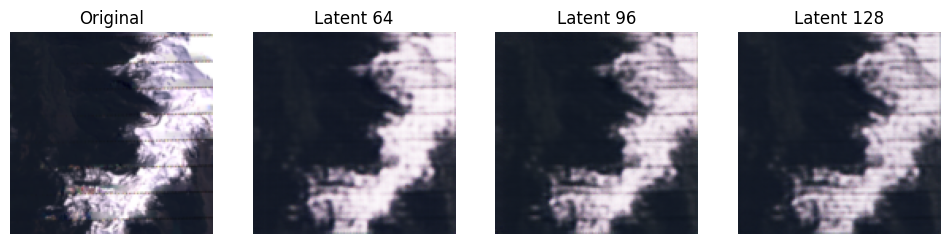

In [20]:
sample = dataset[0]

for i, model in enumerate(models):
    model.eval()
    with torch.no_grad():
        recon, latent = model(sample.unsqueeze(0))
        recon = recon.squeeze(0)

    img_dn = denormalize(sample)
    recon_dn = denormalize(recon)

    print(f"\nLatent Size: {latent_sizes[i]}")
    print("PSNR:", psnr(img_dn, recon_dn).item())
    print("SSIM:", ssim(img_dn, recon_dn).item())
    print("SAM:", sam(img_dn, recon_dn).item())
    print("Compression Ratio:", sample.numel() / latent.numel())

# =============================
# DISPLAY
# =============================
show_results(models, sample)

